<a href="https://colab.research.google.com/github/lvarshitha7/Churn_Analysis/blob/main/Notebook%20(Colab)/Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

file_path=r'/content/Prediction_Data.xlsx'

sheet_name= 'vw_ChurnData'

data=pd.read_excel(file_path,sheet_name=sheet_name)

print(data.head())

  Customer_ID  Gender  Age Married       State  Number_of_Referrals  \
0   11596-KAR  Female   40      No   Karnataka                   15   
1   11604-HAR  Female   38     Yes     Haryana                    4   
2   11616-TAM    Male   26      No  Tamil Nadu                    6   
3   11647-GUJ    Male   44      No     Gujarat                    2   
4   11647-TAM    Male   81      No  Tamil Nadu                    1   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                11     Deal 4           Yes             No  ...   
1                 8        NaN           Yes            Yes  ...   
2                 2        NaN           Yes            Yes  ...   
3                 4     Deal 4           Yes            Yes  ...   
4                21        NaN           Yes            Yes  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      49.200001    571.150024           0.0   
1  Bank Withdrawal     104.400002 

In [6]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

# List of columns to be label encoded

columns_to_encode = [

    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',

    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',

    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',

    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',

    'Payment_Method'

]


# Encode categorical variables except the target variable

label_encoders = {}

for column in columns_to_encode:

    label_encoders[column] = LabelEncoder()

    data[column] = label_encoders[column].fit_transform(data[column])



# Manually encode the target variable 'Customer_Status'

data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})



# Split data into features and target

X = data.drop('Customer_Status', axis=1)

y = data['Customer_Status']


# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Confusion Matrix:
[[830  37]
 [115 220]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       867
           1       0.86      0.66      0.74       335

    accuracy                           0.87      1202
   macro avg       0.87      0.81      0.83      1202
weighted avg       0.87      0.87      0.87      1202



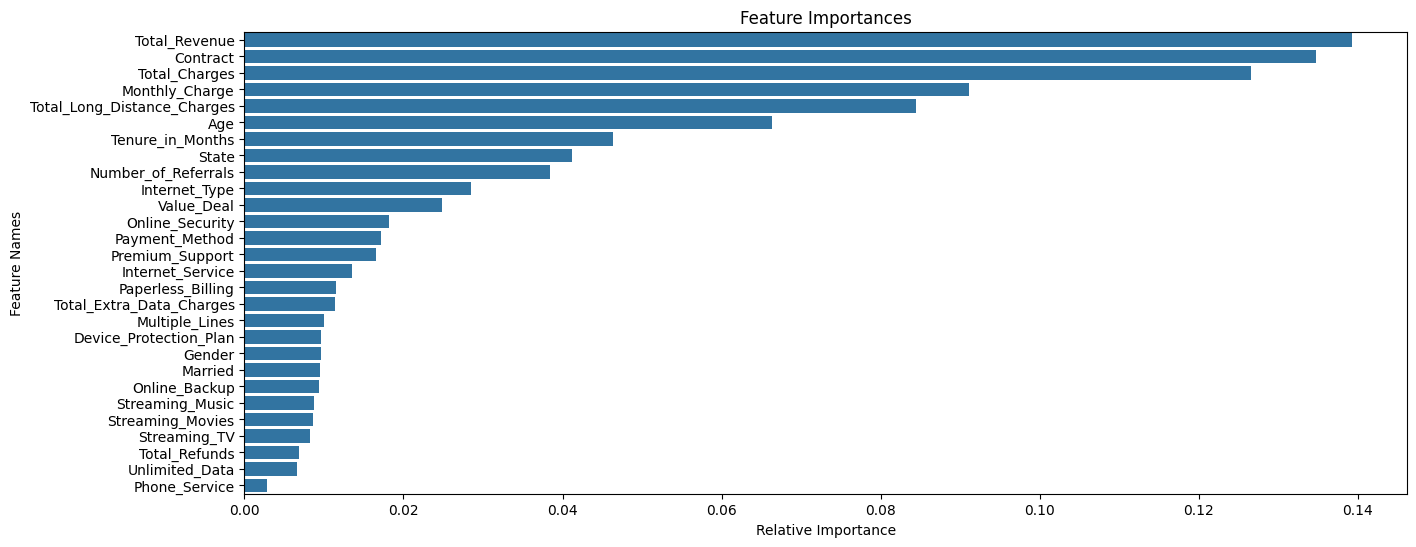

In [7]:
#  Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)



# Train the model

rf_model.fit(X_train, y_train)



# Evaluate Model

# Make predictions

y_pred = rf_model.predict(X_test)



# Evaluate the model

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))



# Feature Selection using Feature Importance

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]



# Plot the feature importances

plt.figure(figsize=(15, 6))

sns.barplot(x=importances[indices], y=X.columns[indices])

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')

plt.show()

In [8]:
# Define the path to the Joiner Data Excel file
file_path = r"/content/Prediction_Data.xlsx"



# Define the sheet name to read data from

sheet_name = 'vw_JoinData'



# Read the data from the specified sheet into a pandas DataFrame

new_data = pd.read_excel(file_path, sheet_name=sheet_name)



# Display the first few rows of the fetched data

print(new_data.head())



# Retain the original DataFrame to preserve unencoded columns

original_data = new_data.copy()



# Retain the Customer_ID column

customer_ids = new_data['Customer_ID']



# Drop columns that won't be used for prediction in the encoded DataFrame

new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)



# Encode categorical variables using the saved label encoders

for column in new_data.select_dtypes(include=['object']).columns:

    new_data[column] = label_encoders[column].transform(new_data[column])



# Make predictions

new_predictions = rf_model.predict(new_data)



# Add predictions to the original DataFrame

original_data['Customer_Status_Predicted'] = new_predictions



# Filter the DataFrame to include only records predicted as "Churned"

original_data = original_data[original_data['Customer_Status_Predicted'] == 1]



# Save the results

original_data.to_csv(r"C:\yourpath\Predictions.csv", index=False)

  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   11751-TAM  Female   18      No     Tamil Nadu                    5   
1   15349-UTT    Male   47     Yes  Uttar Pradesh                    9   
2   17154-HAR    Male   32      No        Haryana                   13   
3   17250-HAR  Female   23     Yes        Haryana                   12   
4   18829-TAM  Female   49     Yes     Tamil Nadu                    4   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 7     Deal 5            No             No  ...   
1                12     Deal 5           Yes            Yes  ...   
2                 4        NaN           Yes             No  ...   
3                 2        NaN           Yes             No  ...   
4                31     Deal 5           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0     Mailed Check      24.299999     38.450001           0.0   
1  Bank Withdraw

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = rf_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.9121761435039338


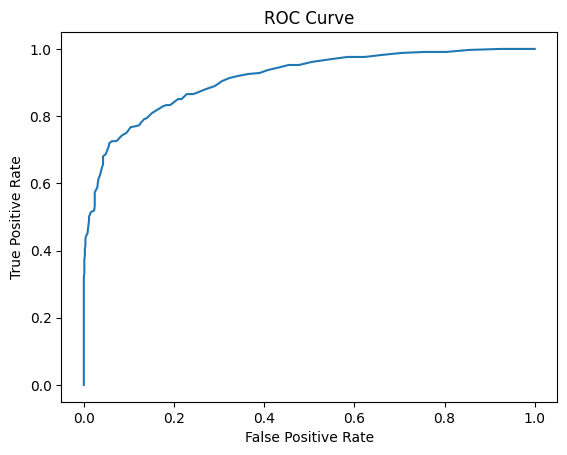

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


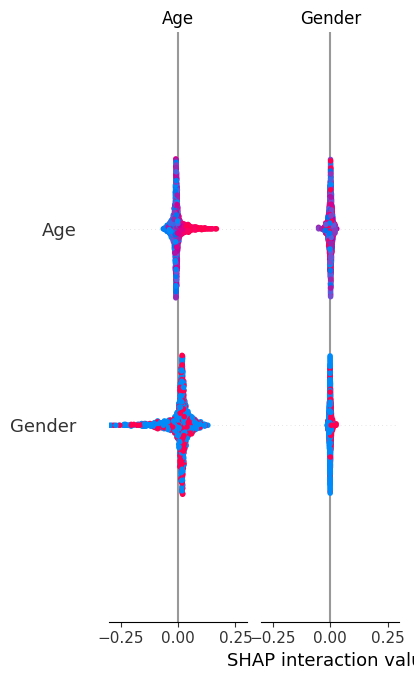

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)